---
tags: [algorithm, optimization, variational]
---

# Alternating Operator Ansatz for Graph Coloring

This tutorial demonstrates how to solve the graph coloring problem with
Qamomile using the Alternating Operator Ansatz (AOA). The AOA formulation
used here follows Hadfield *et al.* {cite:p}`10.3390/a12020034`.

We will proceed as follows:

1. Formulate the problem with [JijModeling](https://jij-inc-jijmodeling-tutorials-en.readthedocs-hosted.com/en/latest/introduction.html) and create an instance with concrete data.
2. Use `AOAConverter` to build the AOA circuit with a chosen mixer and initial state.
3. Optimize the variational parameters with a classical optimizer.
4. Sample the optimized circuit, decode the results, and check that every sample is feasible.

In [1]:
# Install the latest Qamomile through pip!
# !pip install "qamomile[qiskit]"

In [2]:
import os

import jijmodeling as jm
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import ommx.v1
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

import qamomile.circuit as qmc
from qamomile.circuit.algorithm.aoa import xy_mixer
from qamomile.circuit.algorithm.qaoa import ising_cost
from qamomile.circuit.stdlib.state_preparation import prepare_dicke
from qamomile.optimization.aoa import AOAConverter
from qamomile.qiskit import QiskitTranspiler

## Background

AOA extends the QAOA circuit by using more general mixer Hamiltonians and
initial states. This is useful for constrained problems such as graph
coloring.

With the one-hot encoding used below, graph coloring needs $N \times K$
binary variables, but only $K^N$ of the $2^{NK}$ bitstrings are feasible (one
color per node). On the 5-node, 3-color instance below, that is 243 feasible
states inside a $2^{15} = 32768$-dimensional Hilbert space, i.e. less than
$1\%$. Standard QAOA starts in a uniform superposition over the full space and
uses a transverse-field mixer ($\sum X_i$) that freely rotates qubits in and
out of the feasible subspace, so most of the sampled bitstrings violate the
one-hot constraint and get discarded.

AOA addresses both ends: it starts inside the feasible subspace and uses an XY
mixer that only moves amplitude between feasible states, so every sample is
feasible by construction.

## Problem Settings

Given an undirected graph $G = (V, E)$ and a number $K$ of available colors,
the goal is to assign one color to each vertex so that as few edges as
possible connect two vertices of the same color. We call such an edge a
conflict.

**Objective:**

$$
\min \sum_{(u, v) \in E} \sum_{i=0}^{K-1} x_{u, i} x_{v, i}
$$

**Constraint:**

$$
\sum_{i=0}^{K-1} x_{u, i}=1, \forall u \in\{0, \ldots, N-1\}
$$

where $x_{u, i} \in\{0,1\}$ indicates whether color $i$ is used for vertex $u$
or not. The objective counts the number of conflicts.

In [3]:
@jm.Problem.define("Graph Coloring", sense=jm.ProblemSense.MINIMIZE)
def graph_coloring_decorated(problem: jm.DecoratedProblem):
    N = problem.Length()
    K = problem.Natural()

    E = problem.Graph()

    x = problem.BinaryVar(
        shape=(N, K),
        description="$x_{i,k}$ is 1 if node $i$ is colored with color $k$, 0 otherwise",
    )

    problem += jm.sum(x[u, i] * x[v, i] for (u, v) in E for i in K)

    problem += problem.Constraint(
        "ColoringConstraint",
        (jm.sum(x[u, i] for i in K) == 1 for u in N),
        description="Each node must be colored with exactly one color",
    )


graph_coloring_decorated

Problem(name="Graph Coloring", sense=MINIMIZE, objective=sum(E.flat_map(lambda ((u, v): Tuple[natural, natural]): K.map(lambda (i: natural): (u, v, i))).map(lambda ((u, v, i): Tuple[natural, natural, natural]): x[u, i] * x[v, i])), constraints={ColoringConstraint: [Constraint(name="ColoringConstraint", , lambda u: sum(K.map(lambda (i: natural): x[u, i])) == 1, domain=set(N), description="Each node must be colored with exactly one color"),],})

### Reading the constraint as a Hamming-weight condition

The constraint $\sum_{i=0}^{K-1} x_{u,i} = 1$ says that, among the $K$ binary
variables attached to node $u$, exactly one is $1$. When we lay these out as a
bitstring, each node occupies a block of $K$ consecutive qubits, and
feasibility means **each block has Hamming weight exactly 1**.

For our 5-node, 3-color instance the qubit layout is:

```
  [q0 q1 q2] [q3 q4 q5] [q6 q7 q8] [q9 q10 q11] [q12 q13 q14]
   node 0     node 1     node 2     node 3        node 4
```

A feasible state has one `1` in each bracketed block.

### Graph instance

In this tutorial, we use a fixed 5-node graph with 6 edges.

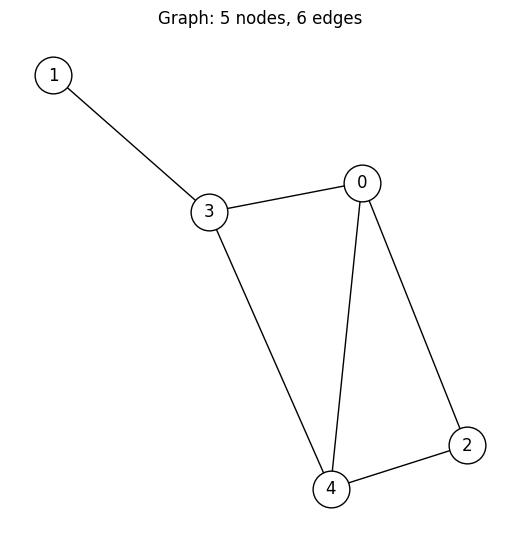

In [4]:
num_nodes = 5
num_colors = 3
edge_list = [(0, 2), (0, 3), (0, 4), (1, 3), (2, 4), (3, 4)]

G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(edge_list)
assert G.number_of_nodes() == num_nodes
assert G.number_of_edges() == len(edge_list)

pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(5, 5))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()

We evaluate the JijModeling problem with the concrete data to obtain an OMMX
instance with $N \times K = 15$ binary variables and one constraint per node.

In [5]:
instance_data = {"N": num_nodes, "E": edge_list, "K": num_colors}
instance = graph_coloring_decorated.eval(instance_data)

assert len(instance.decision_variables) == num_nodes * num_colors
assert len(instance.constraints) == num_nodes

## Algorithm

Like QAOA, AOA alternates a cost layer and a mixer layer $p$ times, starting
from an initial state $\lvert \psi_0 \rangle$:

$$
\lvert \psi(\boldsymbol{\gamma}, \boldsymbol{\beta}) \rangle
= \prod_{l=1}^{p} U_M(\beta_l)\, e^{-i \gamma_l H_C} \lvert \psi_0 \rangle ,
$$

where $H_C$ is the cost Hamiltonian and $U_M$ is the mixer. AOA differs from
QAOA in the choice of $\lvert \psi_0 \rangle$ and $U_M$.

**XY mixer.** The mixer is built from pairwise XY interactions

$$
H_{ij}^{XY}=\frac{1}{2}(X_iX_j+Y_iY_j),
\qquad
U_{ij}^{XY}(\beta)=e^{-i\beta H_{ij}^{XY}}.
$$

On two qubits, $H_{ij}^{XY}$ maps $\lvert 01 \rangle \leftrightarrow \lvert 10 \rangle$
and sends $\lvert 00 \rangle$ and $\lvert 11 \rangle$ to zero. So $U_{ij}^{XY}(\beta)$
mixes the amplitudes of $\lvert 01 \rangle$ and $\lvert 10 \rangle$ without
changing the number of ones. Applying it only to pairs of qubits inside the
same node's color block therefore preserves the one-hot constraint: the single
`1` of each block can move to another color, but it can neither disappear nor
be duplicated.

**Initial state.** The circuit must also start inside the feasible subspace.
A natural choice is a Dicke state in each block: an equal superposition over
all bitstrings with the chosen Hamming weight. For Hamming weight 1 and block
size $K$, each block is prepared in

$$
\lvert D^K_1 \rangle = \frac{1}{\sqrt{K}}
\left(\lvert 10\ldots 0\rangle + \lvert 01\ldots 0\rangle + \cdots + \lvert 0\ldots 01\rangle\right),
$$

so the full initial state is a uniform superposition over all feasible
colorings.

**Cost layer.** The cost layer $e^{-i \gamma H_C}$ is the same as in QAOA. The
optimizer then tunes $\boldsymbol{\gamma}$ and $\boldsymbol{\beta}$ to
concentrate amplitude on colorings with few conflicts.

## Implementation

### Set up the AOAConverter

`AOAConverter` takes an OMMX instance, converts it into QUBO form internally,
and builds the cost Hamiltonian, in the same way as the QAOA converter (see
[QAOA for Graph Partitioning](qaoa_graph_partition) for the converter
workflow). The energy of the decoded samples includes penalty terms, so the
true objective is evaluated separately when decoding.

In [6]:
converter = AOAConverter(instance)
converter.spin_model = converter.spin_model.normalize_by_abs_max()
hamiltonian = converter.get_cost_hamiltonian()
print(hamiltonian)

assert converter.spin_model.num_bits == num_nodes * num_colors

Hamiltonian((Z0,): -1.0, (Z1,): -1.0, (Z2,): -1.0, (Z6,): -0.8, (Z9,): -1.0, (Z12,): -1.0, (Z7,): -0.8, (Z10,): -1.0, (Z13,): -1.0, (Z8,): -0.8, (Z11,): -1.0, (Z14,): -1.0, (Z3,): -0.6, (Z4,): -0.6, (Z5,): -0.6, (Z0, Z1): 0.4, (Z0, Z2): 0.4, (Z0, Z6): 0.2, (Z0, Z9): 0.2, (Z0, Z12): 0.2, (Z1, Z2): 0.4, (Z1, Z7): 0.2, (Z1, Z10): 0.2, (Z1, Z13): 0.2, (Z2, Z8): 0.2, (Z2, Z11): 0.2, (Z2, Z14): 0.2, (Z3, Z4): 0.4, (Z3, Z5): 0.4, (Z3, Z9): 0.2, (Z4, Z5): 0.4, (Z4, Z10): 0.2, (Z5, Z11): 0.2, (Z6, Z7): 0.4, (Z6, Z8): 0.4, (Z6, Z12): 0.2, (Z7, Z8): 0.4, (Z7, Z13): 0.2, (Z8, Z14): 0.2, (Z9, Z10): 0.4, (Z9, Z11): 0.4, (Z9, Z12): 0.2, (Z10, Z11): 0.4, (Z10, Z13): 0.2, (Z11, Z14): 0.2, (Z12, Z13): 0.4, (Z12, Z14): 0.4, (Z13, Z14): 0.4)


### Choose the initial state and mixer

`converter.transpile()` works as in the QAOA case, with extra options to
select the initial state and the XY mixer.

For the initial state, we can choose between:

- `single_basis_state`: a single computational-basis state with the right
  Hamming weight in each block. The converter sets the last qubit(s) of each
  block to $|1\rangle$ (e.g. $|001\rangle|001\rangle\ldots$ in the order
  $q_0 q_1 q_2$, meaning every node starts with the last color). This starts from one valid coloring and
  requires relatively few gates to prepare. The mixer is responsible for
  spreading amplitude to other feasible states.
- `dicke`: a Dicke state in each block, as described above. It costs extra
  gates to prepare ($O(K)$ gates per block) but gives the optimizer an
  unbiased starting point over all feasible colorings.
- `uniform`: a Hadamard gate on every qubit, the standard QAOA initial state.
  **This puts amplitude on infeasible states**, so the feasibility guarantee
  of AOA is lost. It is mainly useful for comparisons of how different
  initial states affect the result.

The `hamming_weight` parameter sets the target Hamming weight per block. For
graph coloring with one-hot encoding it is always `1`. For other problems
(e.g. cardinality-constrained optimization where exactly $k$ items must be
selected), it would be different.

For the mixer, we can select:

- `ring`: connects each qubit in a block only to its two neighbors in a
  cycle. It is applied as odd pairs, then even pairs, then the wrap-around
  pair, so each layer costs $O(K)$ two-qubit gates per block. The circuit is
  shallower, but amplitude takes more layers to spread across the block.
- `fully-connected`: connects every pair of qubits within a block. The
  $\binom{K}{2}$ pairs are split into rounds of non-overlapping pairs, so each
  layer costs $O(K^2)$ two-qubit gates per block. The circuit is deeper, but
  amplitude mixes across the block in a single layer.

As a rule of thumb, prefer `ring` when $K$ is large and circuit depth is the
bottleneck, and `fully-connected` when $K$ is small (say $\leq 4$).

Finally, `block_size` tells the converter how the register is split into
blocks. The Dicke state is prepared inside each block and the mixer only
couples qubits of the same block. For graph coloring, each node owns $K$
qubits whose Hamming weight must stay equal to $1$, so we set
`block_size = num_colors`.

In [7]:
transpiler = QiskitTranspiler()
p = 5  # number of AOA layers

executable_aoa_dicke = converter.transpile(
    transpiler,
    p=p,
    initial_state="dicke",
    hamming_weight=1,
    mixer="fully-connected",
    block_size=num_colors,
)

assert executable_aoa_dicke.quantum_circuit.num_qubits == num_nodes * num_colors

### Visualize the AOA circuit

We draw the transpiled Qiskit circuit, in which the Dicke-state preparation
is already resolved into concrete gates. For readability we use `p=1`.

In [8]:
executable = converter.transpile(
    transpiler,
    p=1,
    initial_state="dicke",
    hamming_weight=1,
    mixer="fully-connected",
    block_size=num_colors,
)

fig = executable.quantum_circuit.draw("mpl", fold=-1, scale=2.2)
fig

### Inspect the building blocks

Inside `aoa_state_dicke`, the converter calls several qkernels:

- `prepare_dicke(n, initial_ones, ...)`: the $X$ gates in the first column
  create a basis state with the given Hamming weight in each block. A
  sequence of $R_Y$ and CNOT gates then builds the Dicke state inside each
  block.
- `ising_cost(quad, linear, q, gamma)`: the cost layer, the same as in QAOA.
  It uses $R_Z$ and $R_{ZZ}$ rotation gates.
- `xy_mixer(q, betas[layer], pair_indices_mixer)`: the mixer layer, which
  applies $U_{ij}^{XY}$ to every pair of qubits listed in
  `pair_indices_mixer`.

`aoa_layers(p, ...)` alternates `ising_cost` and `xy_mixer`, repeated `p`
times.

The converter exposes the Dicke schedule and the mixer pairs it computed from
`block_size`. They are useful for drawing the building blocks, but are not
needed in the normal workflow.

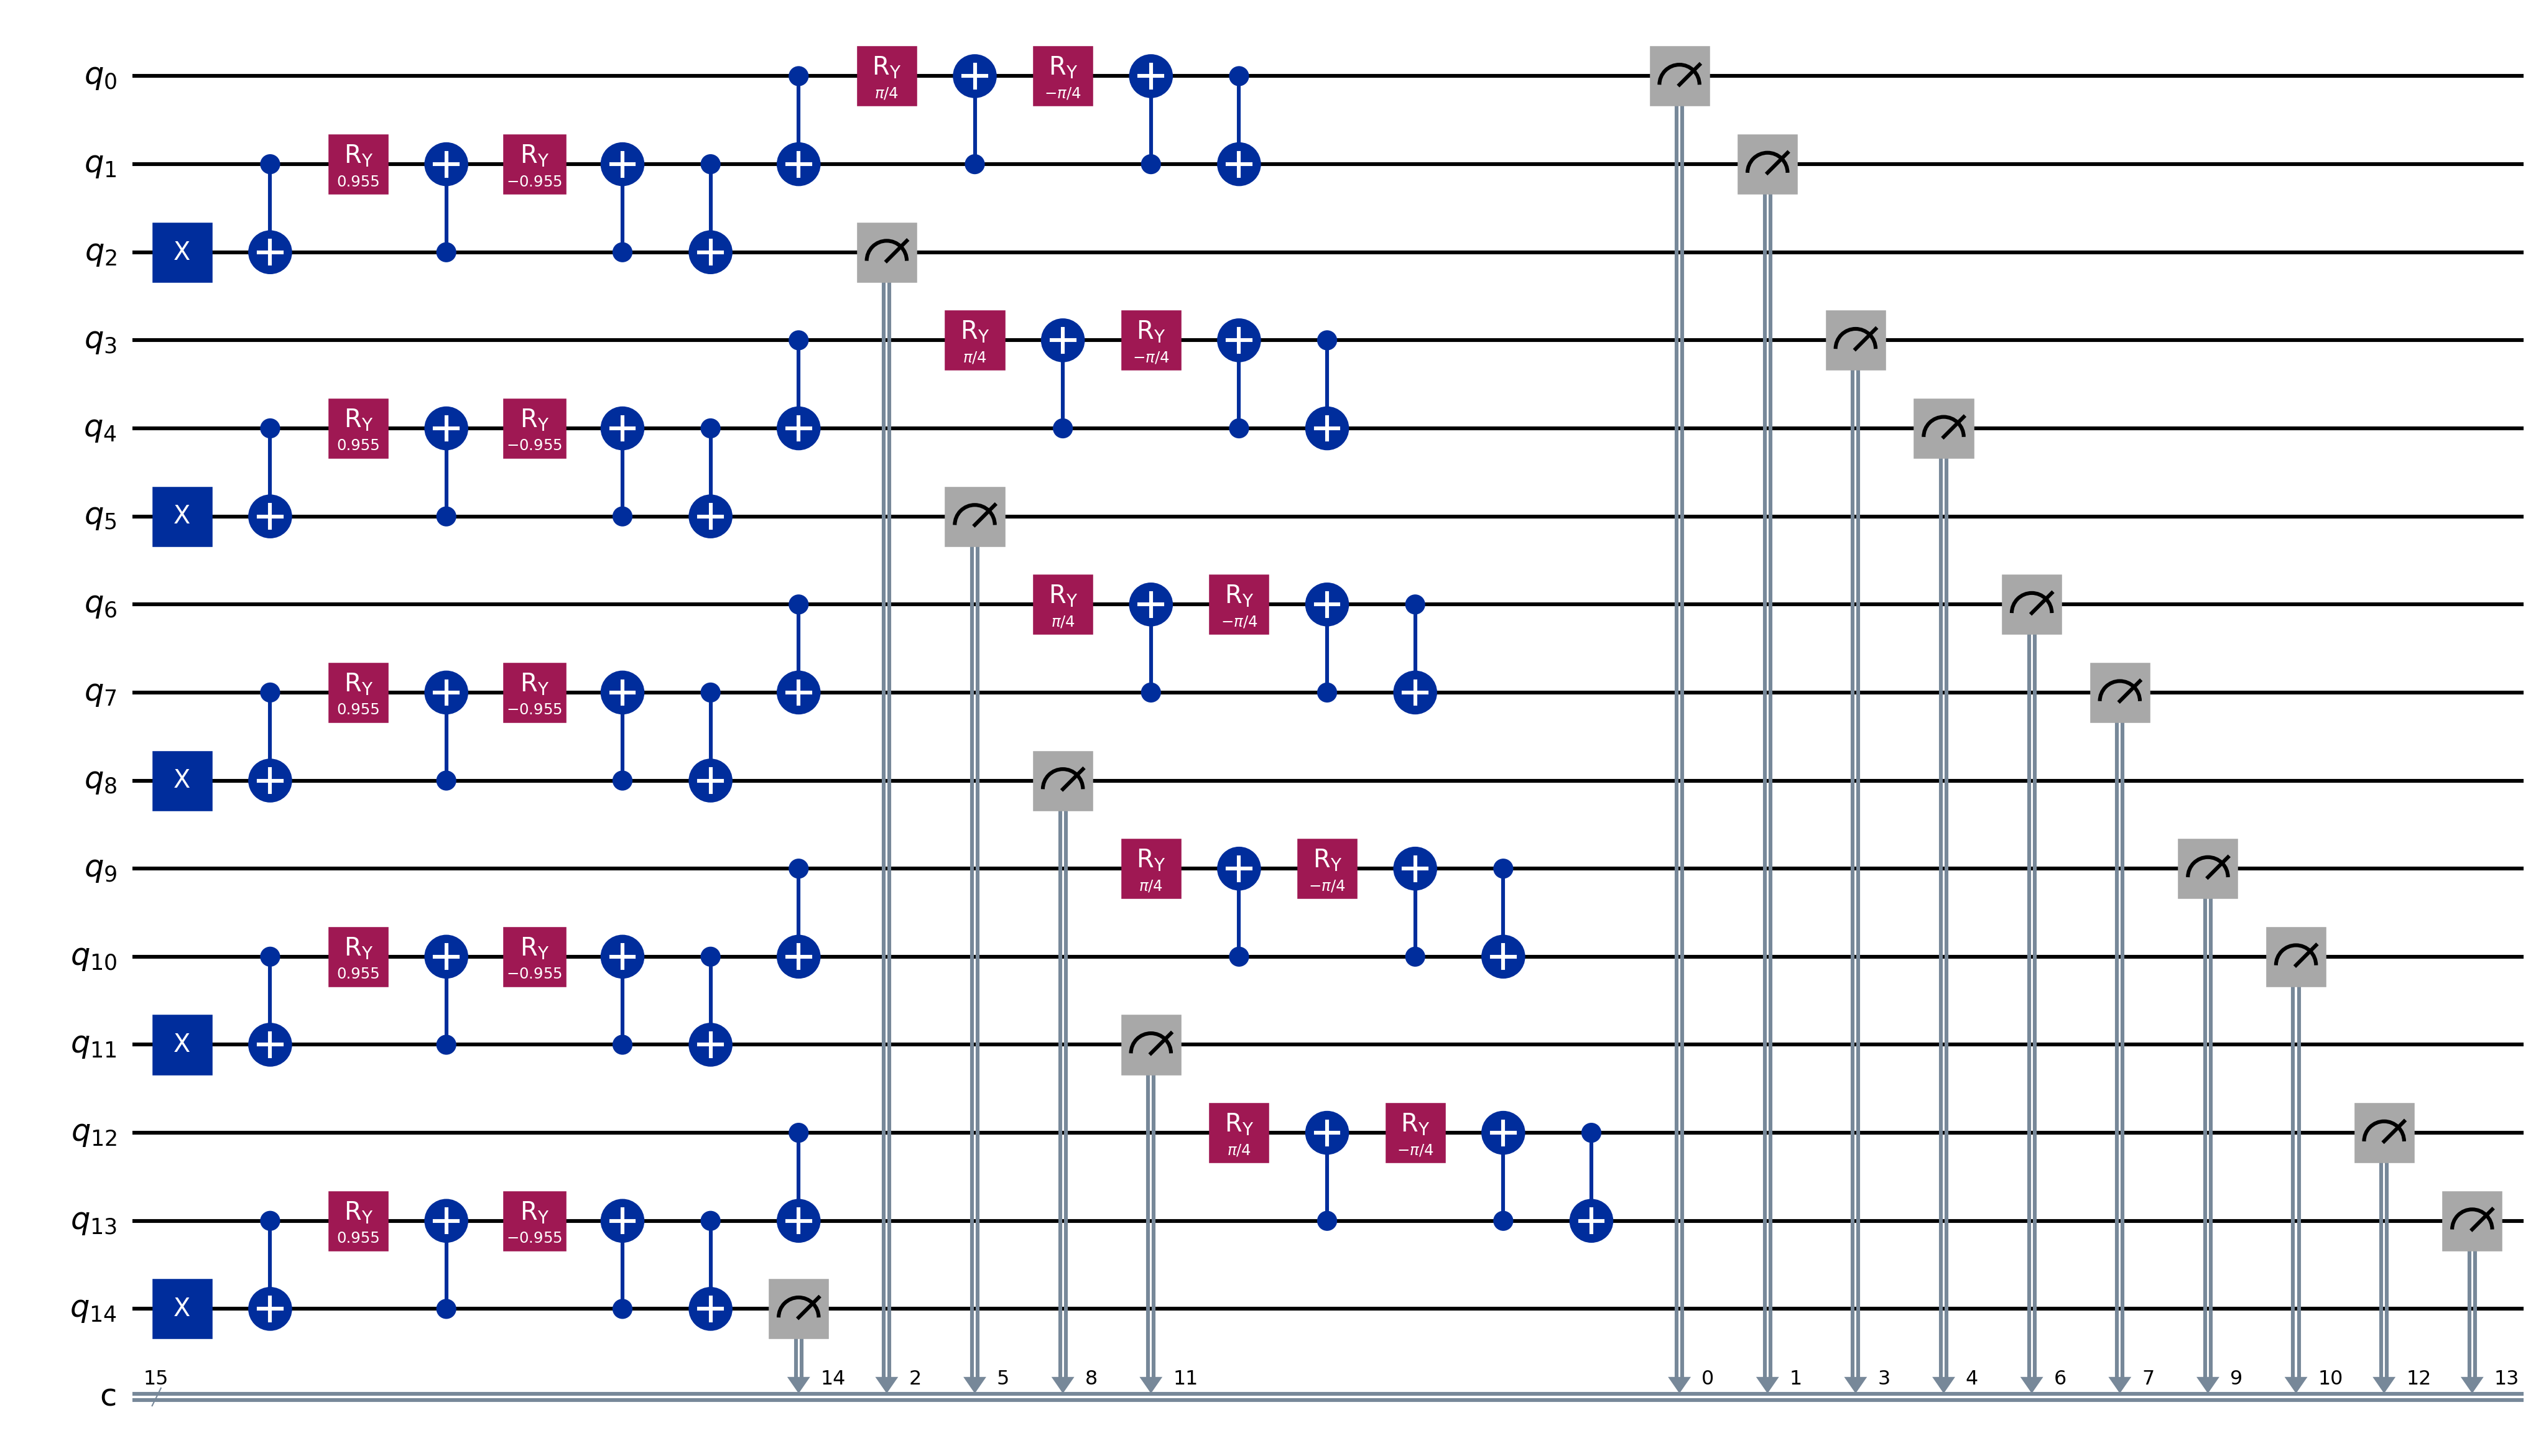

In [9]:
initial_ones, schedule_dicke = converter.compute_dicke_composition_schedule(
    hamming_weight=1, block_size=num_colors
)
resolved_pair = converter.resolve_pair_indices(
    mixer="fully-connected", pair_indices=None, block_size=num_colors
)

# One qubit set to |1> per block, and K(K-1)/2 mixer pairs per block.
assert len(initial_ones) == num_nodes
assert len(resolved_pair) == num_nodes * num_colors * (num_colors - 1) // 2
# Every mixer pair couples two qubits of the same block.
assert all(i // num_colors == j // num_colors for i, j in resolved_pair)


@qmc.qkernel
def prepare_dicke_measure(
    n: qmc.UInt,
    initial_ones: qmc.Vector[qmc.UInt],
    schedule: qmc.Dict[qmc.Vector[qmc.UInt], qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = prepare_dicke(n, initial_ones, schedule)
    return qmc.measure(q)


executable_dicke = transpiler.transpile(
    prepare_dicke_measure,
    bindings={
        "n": converter.spin_model.num_bits,
        "initial_ones": initial_ones,
        "schedule": schedule_dicke,
    },
)

executable_dicke.quantum_circuit.draw("mpl", fold=-1, scale=2.2)

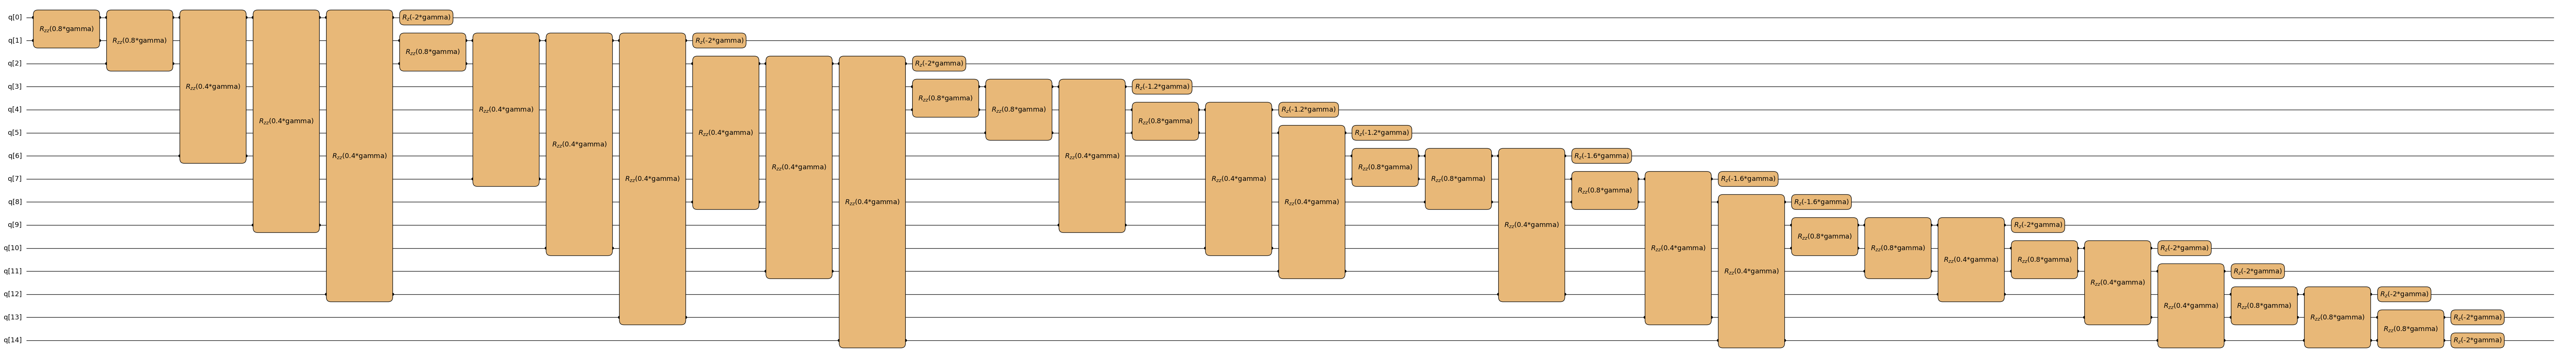

In [10]:
ising_cost.draw(
    q=converter.spin_model.num_bits,
    quad=converter.spin_model.quad,
    linear=converter.spin_model.linear,
    fold_loops=False,
)

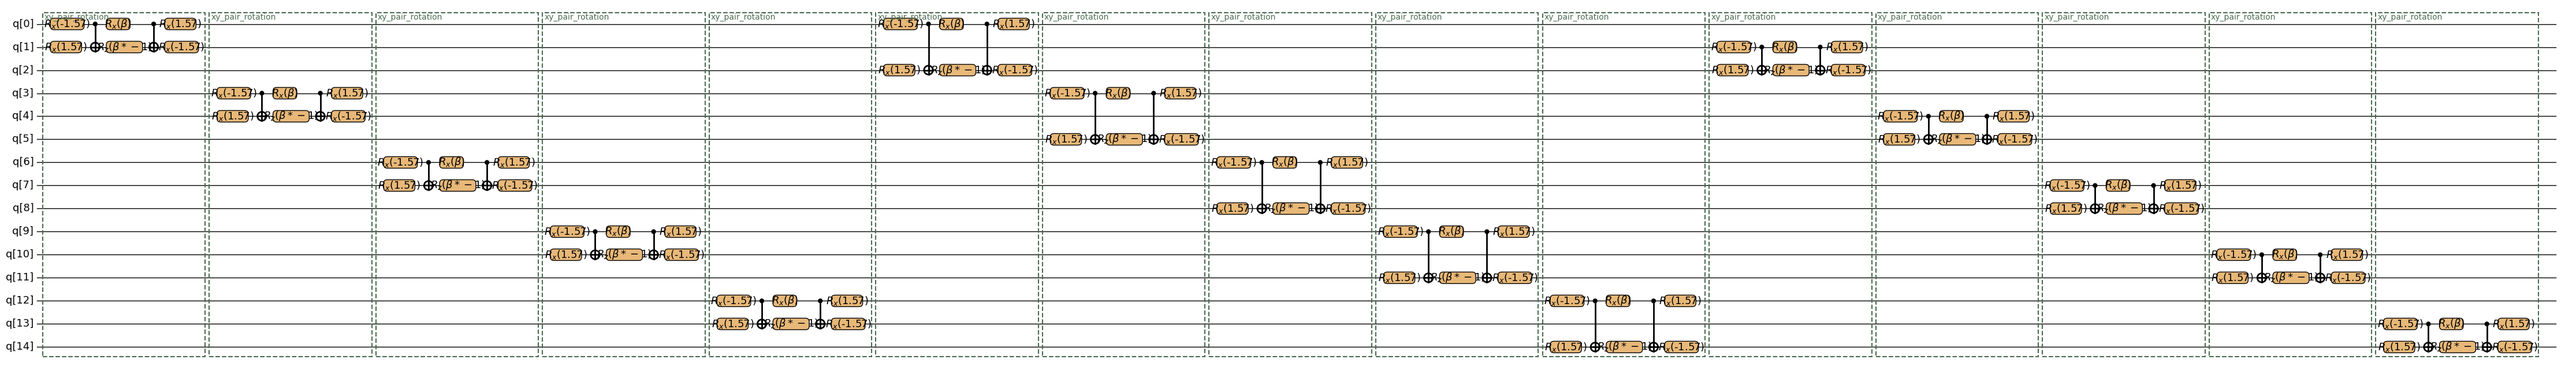

In [11]:
fig = xy_mixer.draw(
    q=converter.spin_model.num_bits,
    pair_indices_mixer=resolved_pair,
    inline=True,
    fold_loops=False,
    expand_composite=True,
    inline_depth=None,
)
fig.set_size_inches(100, 8)
fig

## Result

### Optimize the AOA parameters

We use `executable.sample()` to evaluate the cost at each iteration of the
classical optimizer. The optimizer explores different `gammas` and `betas`
to minimize the mean energy of the sampled bitstrings.

In [12]:
executor = transpiler.executor(
    backend=AerSimulator(seed_simulator=901, max_parallel_threads=1)
)
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2048
maxiter = 25 if docs_test_mode else 1000
final_shots = 64 if docs_test_mode else 1000

rng = np.random.default_rng(900)
initial_params = rng.uniform(0, np.pi, 2 * p)
assert initial_params.shape == (2 * p,)

cost_history = []


def cost_fn(params):
    gammas = list(params[:p])
    betas = list(params[p:])
    job = executable_aoa_dicke.sample(
        executor,
        shots=sample_shots,
        bindings={"gammas": gammas, "betas": betas},
    )
    result = job.result()
    decoded = converter.decode_to_binary_sampleset(result)
    energy = decoded.energy_mean()
    cost_history.append(energy)
    return energy


res = minimize(
    cost_fn,
    initial_params,
    method="COBYLA",
    options={"maxiter": maxiter},
)

print(f"Optimized cost: {res.fun:.3f}")
print(f"Optimal params: {[round(v, 4) for v in res.x]}")
print(f"Function evaluations: {res.nfev}")
assert len(cost_history) == res.nfev
assert len(res.x) == 2 * p

Optimized cost: 1.470
Optimal params: [np.float64(-0.1622), np.float64(0.1793), np.float64(3.6731), np.float64(1.607), np.float64(2.5446), np.float64(1.6097), np.float64(3.3845), np.float64(0.6158), np.float64(1.6647), np.float64(1.0035)]
Function evaluations: 89


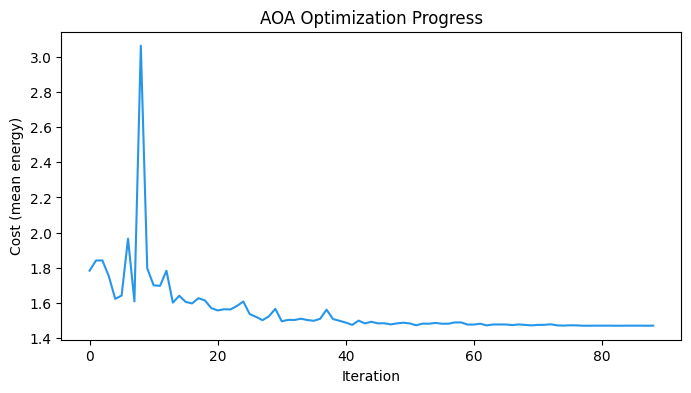

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean energy)")
plt.title("AOA Optimization Progress")
plt.show()

### Sample with the optimized parameters

With the optimized parameters, we sample the circuit to collect candidate
solutions as bitstrings and decode them into an OMMX `SampleSet`.

In [14]:
gammas_opt = list(res.x[:p])
betas_opt = list(res.x[p:])

sample_result = executable_aoa_dicke.sample(
    executor,
    shots=final_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

sample_set = converter.decode(sample_result)
assert isinstance(sample_set, ommx.v1.SampleSet)

### Feasibility check

The problem-specific XY mixer should keep the quantum state within the
feasible subspace throughout the search. Therefore, unlike standard QAOA,
every candidate sampled by this AOA circuit should satisfy the
Hamming-weight-one constraint.

In [15]:
summary = sample_set.summary
total_feasible = int(summary["feasible"].sum())
total_samples = len(summary)

print(
    f"Feasible samples: {total_feasible} / {total_samples} "
    f"({100 * total_feasible / total_samples:.1f}%)"
)
assert total_samples == final_shots
assert total_feasible == total_samples, "AOA must only produce feasible colorings"

Feasible samples: 1000 / 1000 (100.0%)


### Best coloring

`SampleSet.best_feasible` returns the feasible sample with the best (here:
smallest) objective, i.e. the fewest conflicts.

In [16]:
best = sample_set.best_feasible
df = best.decision_variables_df
x_rows = df[df["name"] == "x"]

best_coloring = {}
for _, row in x_rows.iterrows():
    node, color = row["subscripts"]
    if row["value"] > 0.5:
        best_coloring[int(node)] = int(color)

num_conflicts = sum(best_coloring[u] == best_coloring[v] for u, v in edge_list)
print("Best coloring:", best_coloring)
print("Number of conflicts (adjacent nodes with the same color):", num_conflicts)

assert sorted(best_coloring) == list(range(num_nodes))
assert num_conflicts == round(best.objective)

Best coloring: {0: 0, 1: 1, 2: 2, 3: 2, 4: 1}
Number of conflicts (adjacent nodes with the same color): 0


### Objective value distribution

We plot the distribution of the objective value, i.e. the number of
conflicts, over all samples.

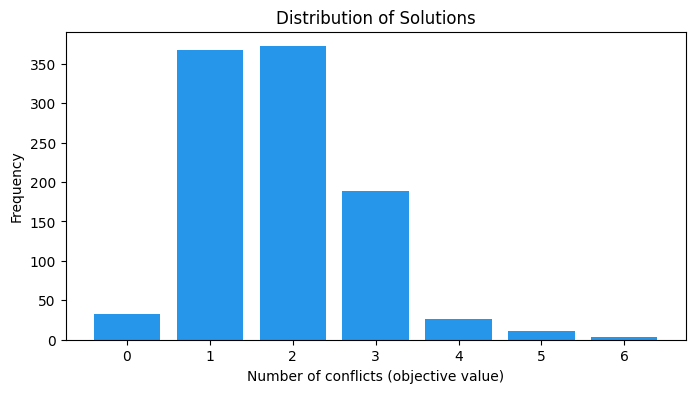

In [17]:
obj_counts = summary["objective"].value_counts().sort_index()
assert obj_counts.sum() == total_samples

plt.figure(figsize=(8, 4))
plt.bar([str(int(o)) for o in obj_counts.index], obj_counts.values, color="#2696EB")
plt.xlabel("Number of conflicts (objective value)")
plt.ylabel("Frequency")
plt.title("Distribution of Solutions")
plt.show()

### Visualize the best coloring

We color the graph nodes according to the best coloring found by AOA.

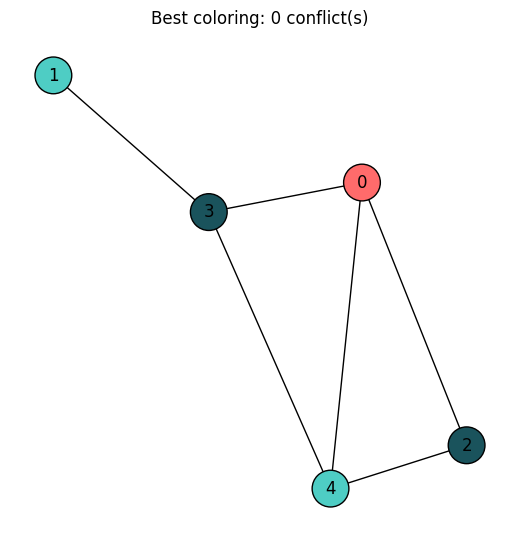

In [18]:
palette = ["#FF6B6B", "#4ECDC4", "#1A535C"]
color_map = [palette[best_coloring[u]] for u in range(num_nodes)]

plt.figure(figsize=(5, 5))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=color_map,
    node_size=700,
    edgecolors="black",
)
plt.title(f"Best coloring: {num_conflicts} conflict(s)")
plt.show()

## Summary

In this notebook, we:

- Solved the graph coloring problem with the Alternating Operator Ansatz,
  using Qamomile's `AOAConverter`.
- Started from a superposition of valid colorings and used a mixer that only
  moves between valid colorings.
- Checked that every sampled solution gives each node exactly one color.